In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.functions import *

In [2]:
path = "dataset/breast-cancer.csv"

data = load_csv(path)

batch = split_xy(data, "diagnosis")

batch = to_numpy(batch)

split_batch = split_train_test(batch)

scaler_state = fit_standard_scaler(
    split_batch[0]
)

encoder_state = fit_label_encoder(
    split_batch[2]
)

split_batch = (
    transform_standard_scaler(
        scaler_state,
        split_batch[0]
    ),

    transform_standard_scaler(
        scaler_state,
        split_batch[1]
    ),

    transform_label_encoder(
        encoder_state,
        split_batch[2]
    ),

    transform_label_encoder(
        encoder_state,
        split_batch[3]
    )
)

train, test = pack_train_test(split_batch)

X_train, y_train = train

Xb, yb = make_batches(
    X_train,
    y_train,
    batch_size=32
)

params = init_params(
    X_train.shape[1]
)

lr = 0.01

In [3]:
for epoch in range(200):

    carry = (params, lr)

    carry, losses = lax.scan(
        step,
        carry,
        (Xb, yb)
    )

    params, _ = carry

    if epoch % 20 == 0:
        print(
            f"epoch={epoch}",
            f"loss={losses[-1]:.4f}"
        )

epoch=0 loss=0.5131
epoch=20 loss=0.2324
epoch=40 loss=0.2111
epoch=60 loss=0.2029
epoch=80 loss=0.1988
epoch=100 loss=0.1965
epoch=120 loss=0.1952
epoch=140 loss=0.1945
epoch=160 loss=0.1942
epoch=180 loss=0.1940


In [4]:
X_test, y_test = test

test_acc = calculate_accuracy(
    params,
    X_test,
    y_test
)
train_acc = calculate_accuracy(
    params,
    X_train,
    y_train
)

******* Accuracy *******
accuracy for test  = 0.99
accuracy for train = 0.98
*** Confusion Matrix ***


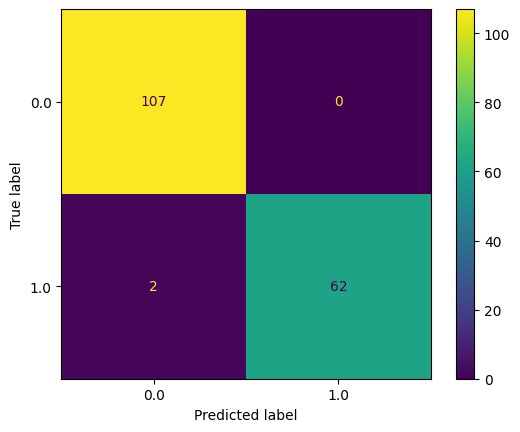

In [5]:
print("******* Accuracy *******")
print(f"accuracy for test  = {test_acc:.2f}")
print(f"accuracy for train = {train_acc:.2f}")
print("*** Confusion Matrix ***")
print(confusion_matrix(y_test, predict(params, X_test)))